# Network Congestion Prediction — Feature Engineering Notebook

**Dataset:** `congestion_training.csv` — 105,982 rows × 57 columns  
**Task:** Multi-class congestion classification (labels 0–4) with temporal feature engineering  
**Key findings pre-notebook:**
- `t` is a simulation timestamp (seconds), irregular sub-second steps, one panel per node
- 6 nodes: `boundary` (majority, 84 K rows), `core0–2`, `edge0–1`
- Two scenarios: `training_congestion` (77 K) and `training_portscan` (28 K)
- Port-scan rows look statistically similar to congestion rows → **treat as anomaly context, not exclude**
- `tcp_synack` is constant zero → **drop**
- `active_flows` is near-binary (0/1) → low signal as continuous
- Pre-engineered composite cols (`traffic_intensity`, `queue_stress`, `iat_pressure`, etc.) are **not** identical to raw cols but derived from them → **leakage risk: keep for EDA but exclude from model features**
- Target: `congestion_label` ∈ {0, 1, 2, 4} (imbalanced: label 2 dominates)

## 1. Imports & Setup

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (14, 4)

DATA_PATH = 'congestion_training.csv'  # adjust path if needed

## 2. Load & Initial Inspection

In [40]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Columns ({len(df.columns)}): {list(df.columns)}')
df.head(3)

Shape: (105982, 57)
Columns (57): ['t', 'node_id', 'scenario', 'bw_in_mbps', 'bw_out_mbps', 'bw_avg_mbps', 'util_in_pct', 'util_out_pct', 'pkt_in', 'pkt_out', 'pkt_dropped', 'pkt_loss_pct', 'bytes_in', 'bytes_out', 'payload_bytes', 'total_bytes', 'jitter_ms', 'iat_mean_ms', 'rtt_avg_ms', 'rtt_std_ms', 'ospf_pkts', 'arp_pkts', 'icmp_pkts', 'udp_pkts', 'tcp_pkts', 'udp_fraction', 'tcp_fraction', 'proto_overhead_pct', 'ospf_overhead_pct', 'tcp_ctrl_pct', 'tcp_syn', 'tcp_synack', 'tcp_fin', 'tcp_rst', 'tcp_retransmit_pct', 'syn_rate_pps', 'rst_rate_pps', 'fin_rate_pps', 'active_flows', 'new_flows', 'finished_flows', 'flow_churn_per_sec', 'peak_kbps_1s_window', 'pkt_asymmetry', 'bw_asymmetry', 'flow_density', 'ctrl_to_data_ratio', 'bytes_per_pkt_out', 'syn_rst_ratio_router', 'tcp_health_score', 'traffic_intensity', 'iat_pressure', 'queue_stress', 'bw_util_ratio', 'drop_rate_trend', 'ctrl_pkt_ratio', 'congestion_label']


,t,node_id,scenario,bw_in_mbps,bw_out_mbps,bw_avg_mbps,util_in_pct,util_out_pct,pkt_in,pkt_out,...,bytes_per_pkt_out,syn_rst_ratio_router,tcp_health_score,traffic_intensity,iat_pressure,queue_stress,bw_util_ratio,drop_rate_trend,ctrl_pkt_ratio,congestion_label
0,10.0,boundary,training_congestion,0.014318,0.008203,0.011261,0.000143,0.000082,149,80,...,128.175000,0.0,1.0,0.011261,13.374454,0.0,0.572915,0.0,0.336245,0
1,10.0,core0,training_congestion,0.016040,0.007440,0.011740,0.000160,0.000074,165,79,...,117.721519,0.0,1.0,0.011740,13.204353,0.0,0.463840,0.0,0.311475,0
2,10.0,core1,training_congestion,0.015554,0.015827,0.015690,0.000156,0.000158,183,135,...,146.548148,0.0,1.0,0.015690,22.663195,0.0,1.017552,0.0,0.408805,0


In [41]:
print('=== dtypes ===')
print(df.dtypes.to_string())
print('\n=== Missing values ===')
miss = df.isnull().sum()
print(miss[miss > 0] if miss.any() else 'None — dataset is complete')
print('\n=== Target distribution ===')
print(df['congestion_label'].value_counts().sort_index())

=== dtypes ===
t                       float64
node_id                  object
scenario                 object
bw_in_mbps              float64
bw_out_mbps             float64
bw_avg_mbps             float64
util_in_pct             float64
util_out_pct            float64
pkt_in                    int64
pkt_out                   int64
pkt_dropped               int64
pkt_loss_pct            float64
bytes_in                  int64
bytes_out                 int64
payload_bytes             int64
total_bytes               int64
jitter_ms               float64
iat_mean_ms             float64
rtt_avg_ms              float64
rtt_std_ms              float64
ospf_pkts                 int64
arp_pkts                  int64
icmp_pkts                 int64
udp_pkts                  int64
tcp_pkts                  int64
udp_fraction            float64
tcp_fraction            float64
proto_overhead_pct      float64
ospf_overhead_pct       float64
tcp_ctrl_pct            float64
tcp_syn                  

In [42]:
# Scenario vs label cross-tab
print('=== Scenario × Congestion Label ===')
print(pd.crosstab(df['scenario'], df['congestion_label'], margins=True))

print('\n=== Node counts ===')
print(df['node_id'].value_counts())

=== Scenario × Congestion Label ===
congestion_label         0      1      2     4     All
scenario                                              
training_congestion  16110   6946  47838  6878   77772
training_portscan     5571   3322  17688  1629   28210
All                  21681  10268  65526  8507  105982

=== Node counts ===
node_id
boundary    84607
core0        4275
core1        4275
core2        4275
edge0        4275
edge1        4275
Name: count, dtype: int64


## 3. Preprocessing & Cleanup

In [43]:
# ── 3.1 Drop constant & near-useless columns ──────────────────────────────
DROP_CONSTANT = ['tcp_synack']  # constant zero in entire dataset

# ── 3.2 Pre-engineered composite columns → LEAKAGE RISK ──────────────────
# These are derived features computed at simulation time from raw signals.
# They are NOT available as true future inputs → exclude from model features.
# Keep for EDA only.
COMPOSITE_LEAKAGE = [
    'traffic_intensity',  # derived from bw_avg_mbps
    'iat_pressure',       # derived from iat_mean_ms
    'queue_stress',       # derived from pkt_loss + queue signals
    'bw_util_ratio',      # derived from bw + util
    'drop_rate_trend',    # derived from pkt_dropped
    'ctrl_pkt_ratio',     # derived from ctrl/data ratio
]

# ── 3.3 Port-scan scenario: tag as anomaly context, don't hard-exclude ────
# Port-scan rows have similar label distributions to congestion rows.
# We encode scenario as a binary feature instead of dropping.
df['is_portscan'] = (df['scenario'] == 'training_portscan').astype(int)

# ── 3.4 Drop unused metadata columns ─────────────────────────────────────
DROP_META = ['scenario']  # encoded above

all_drop = DROP_CONSTANT + DROP_META
df.drop(columns=all_drop, inplace=True)
print(f'Dropped: {all_drop}')
print(f'Remaining columns: {df.shape[1]}')

Dropped: ['tcp_synack', 'scenario']
Remaining columns: 56


In [44]:
# ── 3.5 Encode node_id ────────────────────────────────────────────────────
le_node = LabelEncoder()
df['node_id_enc'] = le_node.fit_transform(df['node_id'])
print('Node encoding:', dict(zip(le_node.classes_, le_node.transform(le_node.classes_))))

Node encoding: {'boundary': np.int64(0), 'core0': np.int64(1), 'core1': np.int64(2), 'core2': np.int64(3), 'edge0': np.int64(4), 'edge1': np.int64(5)}


In [45]:
# ── 3.6 Sort by node + timestamp ─────────────────────────────────────────
df.sort_values(['node_id', 't'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Timestamp gap per node
df['t_diff'] = df.groupby('node_id')['t'].diff().fillna(0)
print('Median time-step per node (seconds):')
print(df.groupby('node_id')['t_diff'].median())

Median time-step per node (seconds):
node_id
boundary    0.57
core0       0.52
core1       0.53
core2       0.54
edge0       0.52
edge1       0.53
Name: t_diff, dtype: float64


## 4. Exploratory Visualizations

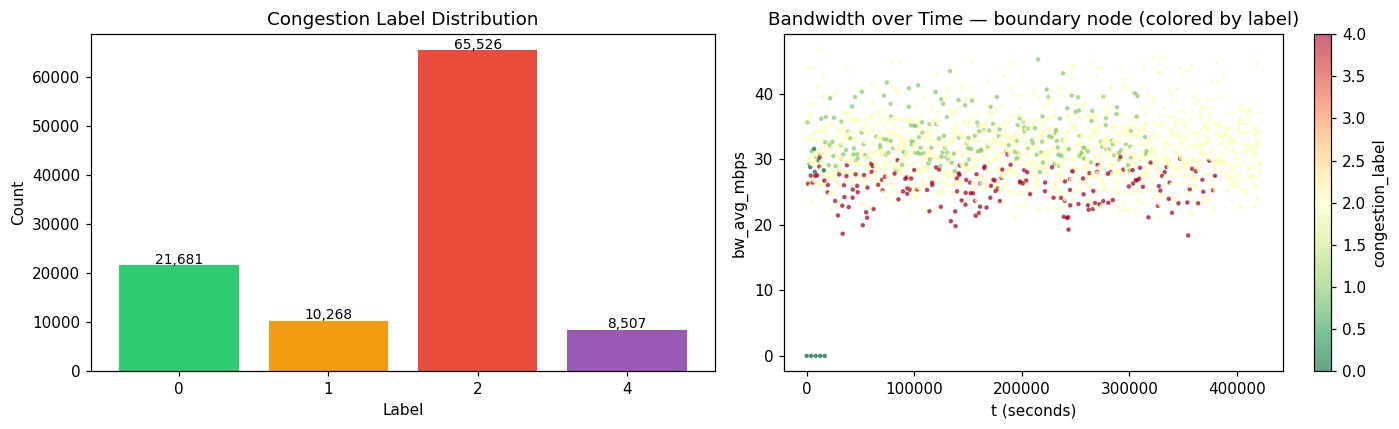

In [46]:
# ── 4.1 Target distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

vc = df['congestion_label'].value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color=['#2ecc71','#f39c12','#e74c3c','#9b59b6'])
axes[0].set_title('Congestion Label Distribution')
axes[0].set_xlabel('Label'); axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontsize=9)

# Bandwidth over time (boundary node)
bnd = df[df['node_id'] == 'boundary'].sort_values('t').copy()
sample = bnd.iloc[::50]  # downsample for plot
sc = axes[1].scatter(sample['t'], sample['bw_avg_mbps'], c=sample['congestion_label'],
                     cmap='RdYlGn_r', s=4, alpha=0.6)
plt.colorbar(sc, ax=axes[1], label='congestion_label')
axes[1].set_title('Bandwidth over Time — boundary node (colored by label)')
axes[1].set_xlabel('t (seconds)'); axes[1].set_ylabel('bw_avg_mbps')
plt.tight_layout(); plt.show()

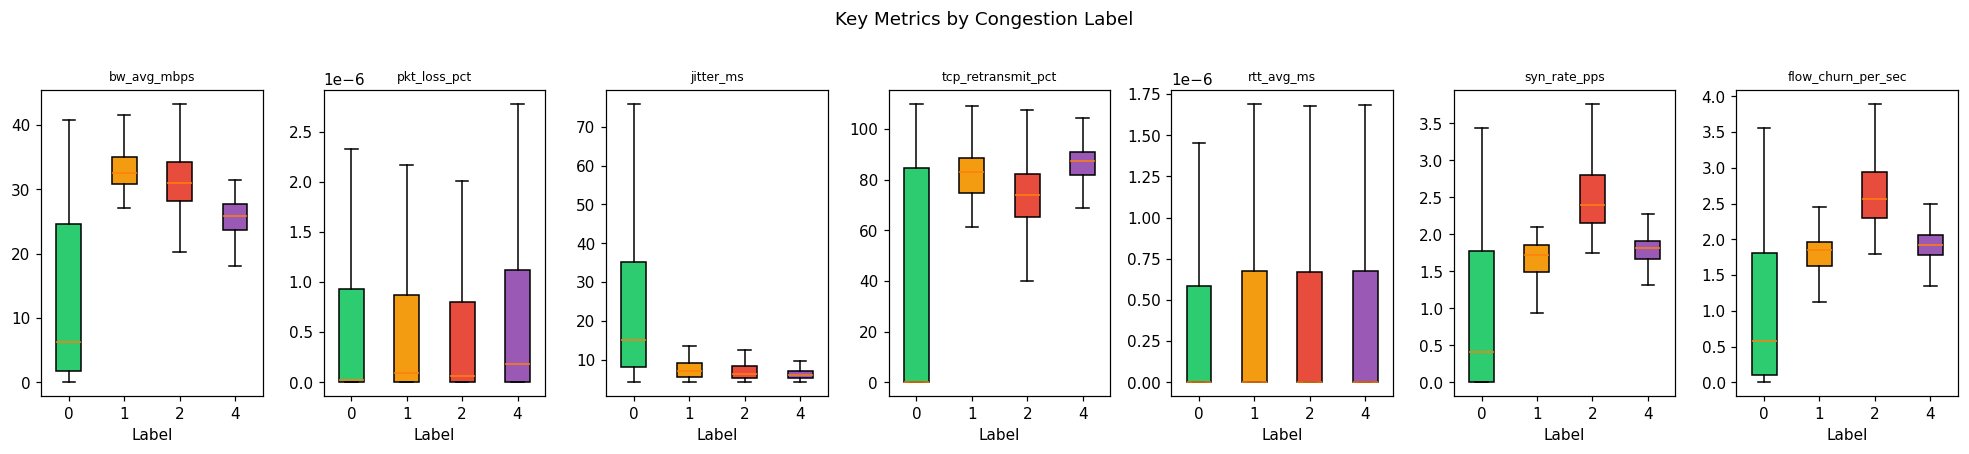

In [47]:
# ── 4.2 Key metrics by label ──────────────────────────────────────────────
metrics = ['bw_avg_mbps', 'pkt_loss_pct', 'jitter_ms', 'tcp_retransmit_pct',
           'rtt_avg_ms', 'syn_rate_pps', 'flow_churn_per_sec']

fig, axes = plt.subplots(1, len(metrics), figsize=(18, 4))
colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c', 4: '#9b59b6'}

for ax, m in zip(axes, metrics):
    grouped = [df[df['congestion_label'] == lbl][m].values for lbl in [0, 1, 2, 4]]
    bp = ax.boxplot(grouped, labels=['0','1','2','4'],
                    patch_artist=True, showfliers=False)
    for patch, lbl in zip(bp['boxes'], [0, 1, 2, 4]):
        patch.set_facecolor(colors[lbl])
    ax.set_title(m, fontsize=8); ax.set_xlabel('Label')

plt.suptitle('Key Metrics by Congestion Label', y=1.02)
plt.tight_layout(); plt.show()

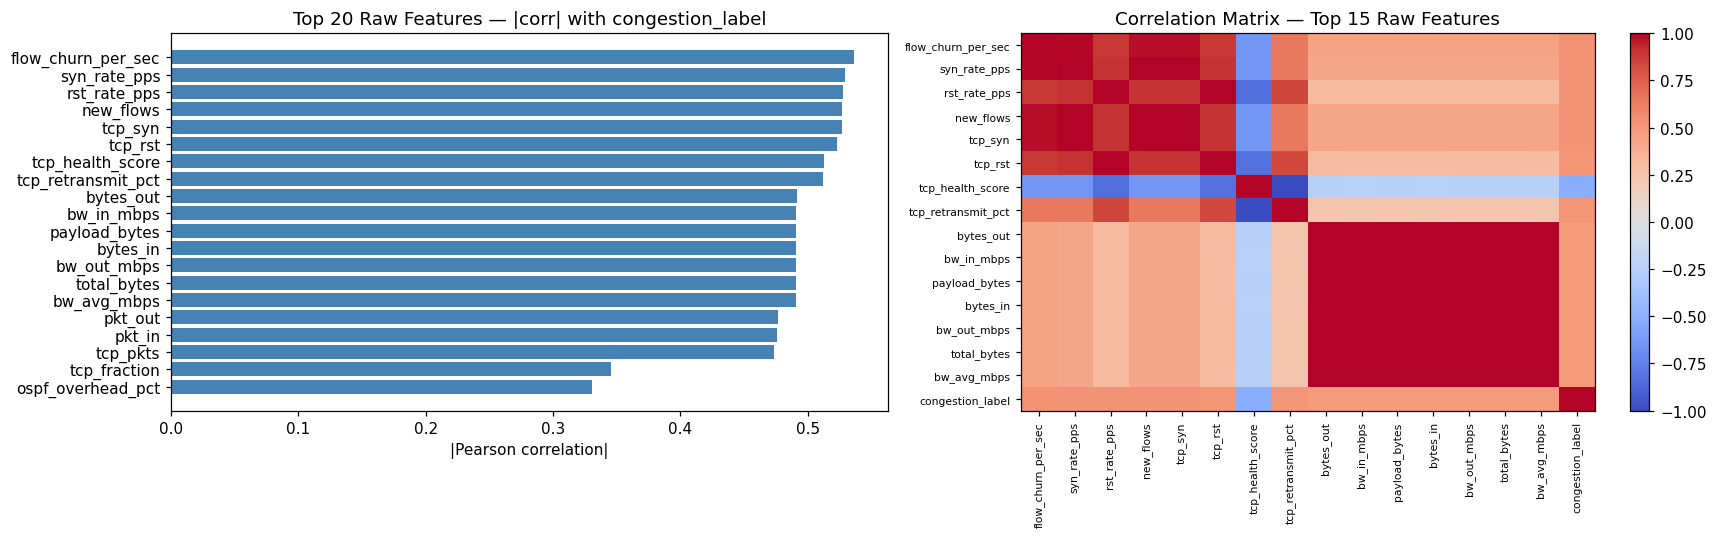

In [48]:
# ── 4.3 Correlation heatmap (raw features) ────────────────────────────────
raw_num_cols = [c for c in df.select_dtypes(include='number').columns
                if c not in COMPOSITE_LEAKAGE + ['congestion_label', 't', 'node_id_enc',
                                                   'is_portscan', 't_diff']]

corr = df[raw_num_cols + ['congestion_label']].corr()
target_corr = corr['congestion_label'].drop('congestion_label').abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top-20 correlations with target
top20 = target_corr.head(20)
axes[0].barh(top20.index[::-1], top20.values[::-1], color='steelblue')
axes[0].set_title('Top 20 Raw Features — |corr| with congestion_label')
axes[0].set_xlabel('|Pearson correlation|')

# Mini heatmap of top-15 features
top15 = list(top20.head(15).index) + ['congestion_label']
mini_corr = df[top15].corr()
im = axes[1].imshow(mini_corr, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(top15))); axes[1].set_xticklabels(top15, rotation=90, fontsize=7)
axes[1].set_yticks(range(len(top15))); axes[1].set_yticklabels(top15, fontsize=7)
plt.colorbar(im, ax=axes[1])
axes[1].set_title('Correlation Matrix — Top 15 Raw Features')

plt.tight_layout(); plt.show()

## 5. Feature Engineering

All lag/rolling features are computed **per node** to avoid cross-node contamination.

In [49]:
# ── Core signals for feature engineering ─────────────────────────────────
# These are the raw, non-leaking, highest-signal columns
CORE_SIGNALS = [
    'bw_avg_mbps', 'bw_in_mbps', 'bw_out_mbps',
    'util_in_pct', 'util_out_pct',
    'pkt_loss_pct', 'pkt_dropped',
    'jitter_ms', 'rtt_avg_ms', 'rtt_std_ms',
    'tcp_retransmit_pct', 'syn_rate_pps', 'rst_rate_pps',
    'flow_churn_per_sec', 'new_flows',
    'peak_kbps_1s_window',
]

# Window sizes (in number of observations per node)
# Median step ~0.5–0.6s → W=5 ≈ 3s, W=10 ≈ 6s, W=30 ≈ 18s
WINDOWS = [5, 10, 30]
LAGS = [1, 3, 5, 10]

fe = df.copy()

In [50]:
# ── 5.1 Lag features ─────────────────────────────────────────────────────
for sig in ['bw_avg_mbps', 'pkt_loss_pct', 'jitter_ms', 'tcp_retransmit_pct', 'syn_rate_pps']:
    for lag in LAGS:
        fe[f'{sig}_lag{lag}'] = fe.groupby('node_id')[sig].shift(lag)

print('Lag features added.')

Lag features added.


In [51]:
# ── 5.2 Rolling statistics (mean, std, max) per node ─────────────────────
for sig in ['bw_avg_mbps', 'pkt_loss_pct', 'jitter_ms', 'tcp_retransmit_pct',
            'flow_churn_per_sec', 'peak_kbps_1s_window']:
    grp = fe.groupby('node_id')[sig]
    for w in WINDOWS:
        fe[f'{sig}_roll_mean_{w}'] = grp.transform(lambda x: x.rolling(w, min_periods=2).mean())
        fe[f'{sig}_roll_std_{w}']  = grp.transform(lambda x: x.rolling(w, min_periods=2).std())

# Rolling max for burst detection
for sig in ['bw_avg_mbps', 'syn_rate_pps', 'pkt_dropped']:
    grp = fe.groupby('node_id')[sig]
    for w in [5, 10]:
        fe[f'{sig}_roll_max_{w}'] = grp.transform(lambda x: x.rolling(w, min_periods=2).max())

print('Rolling stats added.')

Rolling stats added.


In [52]:
# ── 5.3 Rate-of-change features ──────────────────────────────────────────
for sig in ['bw_avg_mbps', 'pkt_loss_pct', 'jitter_ms', 'util_in_pct', 'util_out_pct']:
    grp = fe.groupby('node_id')[sig]
    fe[f'{sig}_delta1']  = grp.diff(1)                          # 1-step change
    fe[f'{sig}_delta5']  = grp.diff(5)                          # 5-step change
    fe[f'{sig}_pct_chg'] = grp.pct_change(fill_method=None)     # % change

print('Rate-of-change features added.')

Rate-of-change features added.


In [53]:
# ── 5.4 Traffic volatility (rolling coeff of variation) ──────────────────
for sig in ['bw_avg_mbps', 'pkt_loss_pct']:
    for w in [10, 30]:
        mu  = fe.groupby('node_id')[sig].transform(lambda x: x.rolling(w, min_periods=3).mean())
        std = fe.groupby('node_id')[sig].transform(lambda x: x.rolling(w, min_periods=3).std())
        fe[f'{sig}_cv_{w}'] = (std / (mu.abs() + 1e-9)).clip(upper=10)

print('Volatility (CV) features added.')

Volatility (CV) features added.


In [54]:
# ── 5.5 Burst indicators ─────────────────────────────────────────────────
# Burst: current value > rolling mean by threshold
for sig in ['bw_avg_mbps', 'syn_rate_pps', 'flow_churn_per_sec']:
    roll_mean = fe.groupby('node_id')[sig].transform(
        lambda x: x.rolling(10, min_periods=3).mean()
    )
    fe[f'{sig}_burst'] = ((fe[sig] - roll_mean) / (roll_mean.abs() + 1e-9)).clip(lower=0)

# SYN flood indicator
fe['syn_flood_indicator'] = (fe['syn_rate_pps'] > fe['syn_rate_pps'].quantile(0.90)).astype(int)

print('Burst indicators added.')

Burst indicators added.


In [55]:
# ── 5.6 Utilization & load ratio features ────────────────────────────────
fe['util_imbalance']    = (fe['util_in_pct'] - fe['util_out_pct']).abs()
fe['util_max']          = fe[['util_in_pct', 'util_out_pct']].max(axis=1)
fe['bw_asym_abs']       = fe['bw_asymmetry'].abs()
fe['loss_per_mbps']     = fe['pkt_loss_pct'] / (fe['bw_avg_mbps'] + 1e-9)   # loss normalized by load
fe['retransmit_load']   = fe['tcp_retransmit_pct'] * fe['bw_avg_mbps']       # congestion pressure
fe['jitter_per_mbps']   = fe['jitter_ms'] / (fe['bw_avg_mbps'] + 1e-9)

print('Load ratio features added.')

Load ratio features added.


In [56]:
# ── 5.7 Temporal features ────────────────────────────────────────────────
# t is not wall-clock but simulation time; encode relative position
fe['t_log'] = np.log1p(fe['t'])   # log-compress for model

# Relative position within each node's timeline
node_t_max = fe.groupby('node_id')['t'].transform('max')
node_t_min = fe.groupby('node_id')['t'].transform('min')
fe['t_relative'] = (fe['t'] - node_t_min) / (node_t_max - node_t_min + 1e-9)

print('Temporal features added.')

Temporal features added.


```markdown
# ── 5.8 Trend: rolling label smoothed score (proxy for momentum) ──────────

**Removed:** Features like `label_lag1` and `label_roll_mean_5` are removed to prevent target leakage, as they are directly derived from the target variable (`congestion_label`). Using these would provide the model with information it wouldn't have in a real-world prediction scenario.
```

In [57]:
# ── 5.9 Fill NaNs from lag/rolling (only at series boundaries) ────────────
print(f'NaNs before fill: {fe.isnull().sum().sum():,}')

# Per-node forward-fill for missing values (e.g., after lag operations)
fe = fe.groupby('node_id', group_keys=False).apply(
    lambda g: g.ffill()
)
# Remaining NaNs (at the start of a series where ffill cannot operate) → fill with 0
fe.fillna(0, inplace=True)
print(f'NaNs after fill: {fe.isnull().sum().sum():,}')

NaNs before fill: 25,972
NaNs after fill: 0


```markdown
## 5.10 Forecasting Setup: Future Target Creation

To convert the classification task into a forecasting one, we define a prediction horizon and create a new target variable that represents the congestion label `FORECAST_HORIZON` steps into the future. This ensures that our model predicts future congestion based only on current and past features.
```

In [58]:
# Define the forecasting horizon
FORECAST_HORIZON = 5 # Example: predict 5 steps (~3 seconds) into the future

# Create a future congestion label by shifting the original label FORWARD
# This operation is grouped by node_id to ensure the shift is performed within each time series.
fe['future_congestion_label'] = fe.groupby('node_id')['congestion_label'].shift(-FORECAST_HORIZON)

print(f"Future target `future_congestion_label` created with horizon: {FORECAST_HORIZON} steps.")
print(f"NaNs introduced in `future_congestion_label`: {fe['future_congestion_label'].isnull().sum():,} (expected at the end of each node's time series)")

Future target `future_congestion_label` created with horizon: 5 steps.
NaNs introduced in `future_congestion_label`: 30 (expected at the end of each node's time series)


```markdown
## 5.11 Causal Feature Engineering

All rolling-window and aggregation operations in this notebook are designed to be strictly causal. This means:

*   **Right-aligned windows:** The `rolling()` method in pandas, by default, uses a trailing window. This ensures that any statistic (mean, standard deviation, max) calculated for a given timestamp only includes data from that timestamp and preceding ones.
*   **Past-looking shifts:** Lag (`shift()`) and difference (`diff()`) features explicitly look at prior observations.
*   **Future-shifted target:** The `future_congestion_label` is created by shifting the original label forward. This is the correct approach for a forecasting task, where we predict a future outcome based on current and past features. The features themselves (e.g., `X_train`, `X_val`) are carefully constructed to only contain information observable at or before the time point for which the future target is being predicted.

This causal design is crucial for preventing future leakage and ensuring the model can be effectively deployed in a real-time forecasting scenario.
```

## 6. Define Feature Sets

In [59]:
TARGET = 'future_congestion_label' # Updated for forecasting setup

# Columns to always exclude from features
EXCLUDE = (
    [TARGET, 'congestion_label', 'node_id', 't', 't_diff', 'split'] + # 'congestion_label' and 'split' are now also excluded
    COMPOSITE_LEAKAGE +           # pre-engineered at sim time — leakage risk
    ['label_lag1', 'label_roll_mean_5', 'tcp_health_score'] # Removed due to target leakage or heuristic proxy
)

FEATURE_COLS = [c for c in fe.select_dtypes(include='number').columns
                if c not in EXCLUDE]

print(f'Total feature count: {len(FEATURE_COLS)}')
print(f'\nSample features:')
print([c for c in FEATURE_COLS if 'roll' in c or 'lag' in c or 'burst' in c][:20])

Total feature count: 140

Sample features:
['bw_avg_mbps_lag1', 'bw_avg_mbps_lag3', 'bw_avg_mbps_lag5', 'bw_avg_mbps_lag10', 'pkt_loss_pct_lag1', 'pkt_loss_pct_lag3', 'pkt_loss_pct_lag5', 'pkt_loss_pct_lag10', 'jitter_ms_lag1', 'jitter_ms_lag3', 'jitter_ms_lag5', 'jitter_ms_lag10', 'tcp_retransmit_pct_lag1', 'tcp_retransmit_pct_lag3', 'tcp_retransmit_pct_lag5', 'tcp_retransmit_pct_lag10', 'syn_rate_pps_lag1', 'syn_rate_pps_lag3', 'syn_rate_pps_lag5', 'syn_rate_pps_lag10']


## 7. Train / Validation Split (Temporal)

We split **by timestamp** to respect temporal ordering — no random shuffle.

In [60]:
# Split at 80th percentile of t per node (chronological)
SPLIT_PCT = 0.80

def temporal_split(group, pct=SPLIT_PCT):
    cutoff = group['t'].quantile(pct)
    group['split'] = np.where(group['t'] <= cutoff, 'train', 'val')
    return group

# Filter out rows where the future target is NaN (due to shifting)
fe_filtered = fe.dropna(subset=[TARGET]).copy()

# Apply the temporal split per node on the filtered data
fe_filtered = fe_filtered.groupby('node_id', group_keys=False).apply(temporal_split)

train = fe_filtered[fe_filtered['split'] == 'train']
val   = fe_filtered[fe_filtered['split'] == 'val']

X_train = train[FEATURE_COLS]
y_train = train[TARGET]
X_val   = val[FEATURE_COLS]
y_val   = val[TARGET]

print(f'Train: {len(X_train):,} rows | Val: {len(X_val):,} rows')
print('\nTrain label dist:')
print(y_train.value_counts().sort_index())
print('\nVal label dist:')
print(y_val.value_counts().sort_index())

Train: 84,761 rows | Val: 21,191 rows

Train label dist:
future_congestion_label
0.0    17381
1.0    10268
2.0    49921
4.0     7191
Name: count, dtype: int64

Val label dist:
future_congestion_label
0.0     4270
2.0    15605
4.0     1316
Name: count, dtype: int64


## 8. Baseline Model — Random Forest

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

# Handle potential infinite values in X_train and X_val
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_val.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill any NaNs (including those just created from inf) with 0
X_train.fillna(0, inplace=True)
X_val.fillna(0, inplace=True)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)

# Get the unique labels from the combined train/val set, or just from the model's classes_
# This ensures that target_names correctly reflects all possible labels.
all_possible_labels = np.unique(np.concatenate((y_train.unique(), y_val.unique())))
# Sort labels for consistent ordering in the report
all_possible_labels.sort()

# Create target names from these labels
report_target_names = [f'label_{int(lbl)}' for lbl in all_possible_labels]

print('=== Classification Report (Validation) ===')
print(classification_report(y_val, y_pred, labels=all_possible_labels, target_names=report_target_names))

=== Classification Report (Validation) ===
              precision    recall  f1-score   support

     label_0       1.00      1.00      1.00      4270
     label_1       0.00      0.00      0.00         0
     label_2       0.96      0.92      0.94     15605
     label_4       0.46      0.50      0.48      1316

    accuracy                           0.91     21191
   macro avg       0.61      0.61      0.61     21191
weighted avg       0.94      0.91      0.92     21191



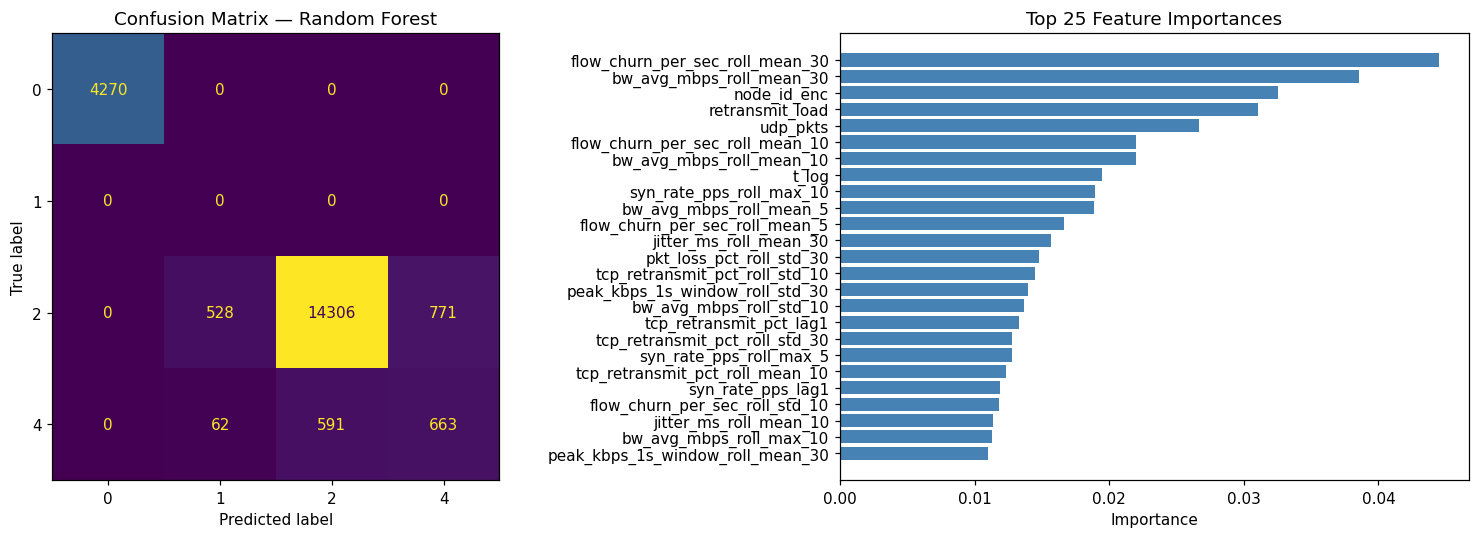

In [68]:
import numpy as np # Ensure numpy is imported
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Ensure necessary imports are present
import matplotlib.pyplot as plt
import pandas as pd

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Re-define all_possible_labels and report_target_names for independent execution
all_possible_labels = np.unique(np.concatenate((y_train.unique(), y_val.unique())))
all_possible_labels.sort()
report_target_names = [f'label_{int(lbl)}' for lbl in all_possible_labels]

# Use the same labels for ConfusionMatrixDisplay for consistency
ConfusionMatrixDisplay(
    confusion_matrix(y_val, y_pred, labels=all_possible_labels),
    display_labels=[f'{int(lbl)}' for lbl in all_possible_labels]
).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — Random Forest')

# Feature importances (top 25)
fi = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False).head(25)
axes[1].barh(fi.index[::-1], fi.values[::-1], color='steelblue')
axes[1].set_title('Top 25 Feature Importances')
axes[1].set_xlabel('Importance')

plt.tight_layout(); plt.show()

## 9. Anomaly / Port-Scan Detection Sidetrack

Port-scan rows are encoded as `is_portscan=1`. We verify whether they cluster distinctly.

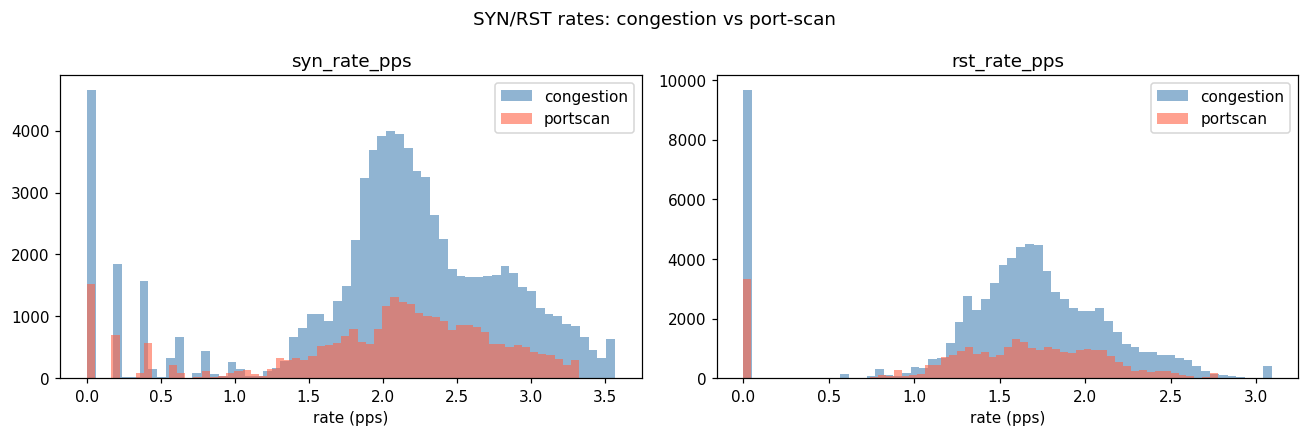

Mean SYN rate — congestion: 2.041 | portscan: 2.008


In [63]:
# Quick separation check: SYN rate + RST rate by scenario type
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, sig in zip(axes, ['syn_rate_pps', 'rst_rate_pps']):
    for val_flag, label, color in [(0, 'congestion', 'steelblue'), (1, 'portscan', 'tomato')]:
        subset = fe[fe['is_portscan'] == val_flag][sig]
        ax.hist(subset.clip(upper=subset.quantile(0.995)), bins=60, alpha=0.6, label=label, color=color)
    ax.set_title(sig); ax.legend(); ax.set_xlabel('rate (pps)')

plt.suptitle('SYN/RST rates: congestion vs port-scan')
plt.tight_layout(); plt.show()

# Conclusion: if distributions strongly overlap, port-scan rows are safe to keep
print('Mean SYN rate — congestion:', fe[fe['is_portscan']==0]['syn_rate_pps'].mean().round(3),
      '| portscan:', fe[fe['is_portscan']==1]['syn_rate_pps'].mean().round(3))

## 10. Save Processed Dataset

In [66]:
OUT_COLS = ['node_id', 't', TARGET, 'is_portscan'] + FEATURE_COLS
fe_out = fe.dropna(subset=[TARGET]).copy() # Drop rows where future target is NaN before saving

fe_out[OUT_COLS].to_csv('congestion_features_engineered.csv', index=False)
print(f'Saved: congestion_features_engineered.csv — {fe_out.shape[0]:,} rows × {len(OUT_COLS)} columns')

# Also save feature list for reproducibility
pd.Series(FEATURE_COLS).to_csv('feature_list.csv', index=False, header=['feature'])
print(f'Feature list saved: feature_list.csv ({len(FEATURE_COLS)} features)')

Saved: congestion_features_engineered.csv — 105,952 rows × 144 columns
Feature list saved: feature_list.csv (140 features)


---
## Summary & Recommendations

### Target Variable
**`congestion_label`** — multi-class (0, 1, 2, 4). Treat as ordinal classification.  
Class imbalance: label 2 is 62% of data → use `class_weight='balanced'` or focal loss.

### Leakage Columns — Exclude from Models
| Column | Reason |
|---|---|
| `traffic_intensity` | Derived from `bw_avg_mbps` at sim time |
| `queue_stress` | Derived congestion composite |
| `iat_pressure` | IAT-based composite |
| `bw_util_ratio` | BW/util ratio composite |
| `drop_rate_trend` | Packet drop trend composite |
| `ctrl_pkt_ratio` | Control packet ratio composite |
| `tcp_synack` | Constant zero — drop |

### Port-Scan Handling
Port-scan rows share similar congestion label distributions and feature ranges.  
**Recommendation:** Keep them, encode `is_portscan` as a binary feature.  
If anomaly isolation is needed, use Isolation Forest on SYN/RST/flow burst features.

### Top Engineered Features
1. `bw_avg_mbps_roll_mean_{5,10,30}` — throughput trend
2. `tcp_retransmit_pct_lag{1,3,5}` — retransmit momentum
3. `flow_churn_per_sec_burst` — sudden flow activity burst
4. `syn_rate_pps_roll_max_10` — SYN burst window
5. `jitter_ms_delta1` — jitter acceleration
6. `pkt_loss_pct_cv_30` — loss volatility
7. `retransmit_load` = `tcp_retransmit_pct × bw_avg_mbps`
8. `util_imbalance` — asymmetric utilization
9. `loss_per_mbps` — normalized loss under load

### Window Sizes
- **Historical window:** 10–30 observations (~5–18 seconds)
- **Forecast horizon:** 1–5 steps ahead (~1–3 seconds) for operational use

### Recommended Model Families
| Model | Why |
|---|---|
| **LightGBM / XGBoost** | Best baseline; handles imbalance, fast |
| **Random Forest** | Robust, interpretable, good default |
| **Temporal Fusion Transformer** | If multi-node sequence modeling is needed (justifies deep learning given 100K+ rows with clear temporal structure) |
| **Isolation Forest** (sidecar) | For port-scan / anomaly flagging |

### ML Framing
**Primary:** Multi-class classification (`congestion_label`)  
**Optional extension:** Treat as ordinal regression (0 < 1 < 2 < 4) with thresholded outputs  
**Future:** Sequence prediction (LSTM/TFT) if online forecasting horizon > 5 steps is required